In [1]:
# Hidden setup cell (imports, deterministic seed, global dt).
%matplotlib inline
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Perceptual Decision-Making with Wong-Wang

The **Wong-Wang** model (Wong & Wang, 2006) is the canonical reduced circuit for a two-choice
perceptual decision. Two populations of neurons — one for each choice — compete through
recurrent self-excitation and mutual inhibition. The competition makes the circuit **bistable**:
from a symmetric resting state it commits to one of two high-activity attractors. A sensory
**evidence** signal (motion `coherence`) biases which attractor wins, and the slow ramp of the
synaptic gating variables `S1`/`S2` is the model's signature of **evidence accumulation**.

This case study demonstrates:

1. **evidence accumulation** — the gating variables ramping to a decision under noise,
2. **bistability** — symmetric (zero-evidence) trials breaking left or right at random, and
3. a **psychometric** sweep — choice probability vs. evidence strength.

**Reference:** Wong & Wang (2006), *A recurrent network mechanism of time integration in
perceptual decisions*, J. Neurosci. 26(4):1314-1328. The model is bundled as
{class}`~brainmass.WongWangStep` — no external data needed.

:::{note}
{class}`~brainmass.WongWangStep` is the reduced **two-variable decision** model (states `S1`,
`S2`; `update(coherence=...)`), distinct from {class}`~brainmass.WongWangExcInhStep`, the
excitatory/inhibitory mean-field model used for resting-state BOLD.
:::

## 1. A single decision trial

We drive the circuit with a constant rightward **coherence** (favoring population 1) and inject
small current noise into each population so trials are stochastic. The firing rates `r1`, `r2`
start together, then one wins. The whole trial is compiled into a single
{func}`brainstate.transform.for_loop` — the brainmass idiom for running a model many steps — so
each trial is fast and we can run dozens of them below.

In [2]:
dt = 0.1 * u.ms

def run_trial(coherence, *, duration=1000.0 * u.ms, sigma=0.02 * u.nA, seed=0):
    """Run one Wong-Wang decision trial; return time, rates (r1, r2), gating (S1, S2)."""
    brainstate.random.seed(seed)
    model = brainmass.WongWangStep(
        in_size=1,
        noise_s1=brainmass.GaussianNoise(1, sigma=sigma),
        noise_s2=brainmass.GaussianNoise(1, sigma=sigma),
    )
    brainstate.nn.init_all_states(model)
    n_steps = int(duration / dt)

    def step(i):
        r1, r2 = model.update(coherence=coherence)
        return (u.get_magnitude(r1[0]), u.get_magnitude(r2[0]),
                model.S1.value[0], model.S2.value[0])

    with brainstate.environ.context(dt=dt):
        r1s, r2s, s1s, s2s = brainstate.transform.for_loop(step, np.arange(n_steps))
    ts = (np.arange(n_steps) + 1) * u.get_magnitude(dt)
    return ts, np.asarray(r1s), np.asarray(r2s), np.asarray(s1s), np.asarray(s2s)

ts, r1, r2, s1, s2 = run_trial(coherence=0.25, seed=1)
winner = 1 if s1[-1] > s2[-1] else 2
print(f"coherence = +0.25 (favors pop 1)  ->  winner: population {winner}")
print(f"final gating: S1 = {s1[-1]:.3f}, S2 = {s2[-1]:.3f}")

coherence = +0.25 (favors pop 1)  ->  winner: population 1
final gating: S1 = 0.763, S2 = 0.759


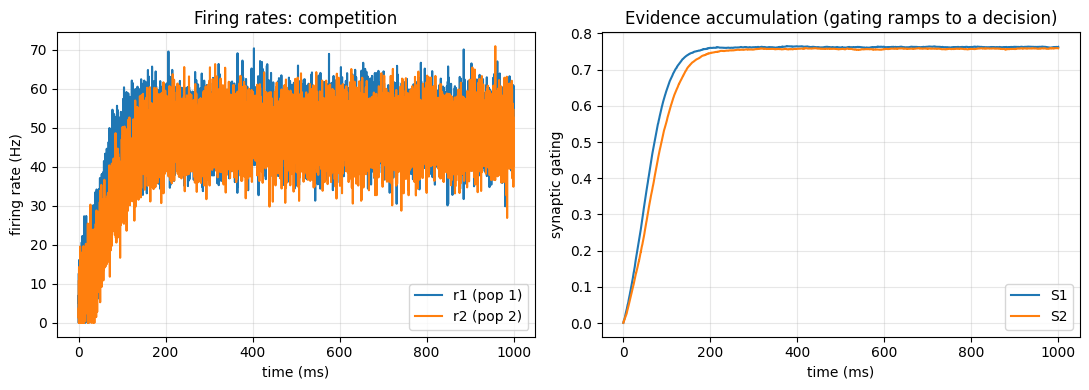

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ts, r1, label='r1 (pop 1)'); ax1.plot(ts, r2, label='r2 (pop 2)')
ax1.set_xlabel('time (ms)'); ax1.set_ylabel('firing rate (Hz)')
ax1.set_title('Firing rates: competition'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ts, s1, label='S1'); ax2.plot(ts, s2, label='S2')
ax2.set_xlabel('time (ms)'); ax2.set_ylabel('synaptic gating')
ax2.set_title('Evidence accumulation (gating ramps to a decision)')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Bistability under zero evidence

With **no** evidence (`coherence = 0`) the circuit is symmetric, but noise still pushes it into
one of the two attractors — and *which* one varies trial to trial. Running several zero-coherence
trials with different noise seeds shows the spontaneous left/right split that is the hallmark of
a bistable decision circuit.

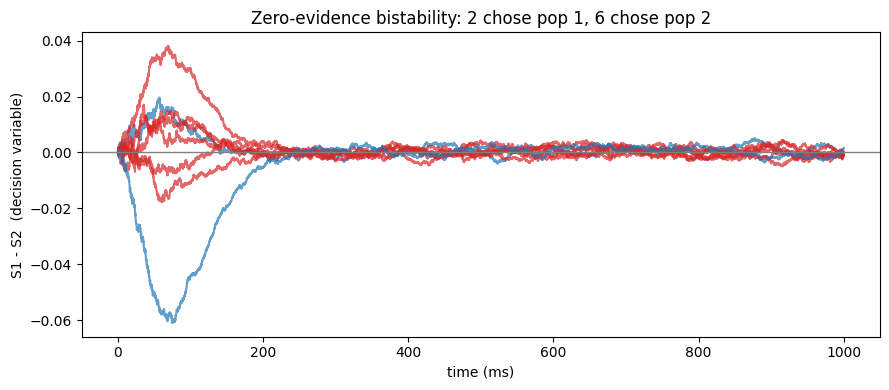

per-trial choices (zero coherence): [1, 2, 2, 2, 2, 2, 2, 1]


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
n_trials = 8
choices = []
for seed in range(n_trials):
    t, _, _, s1_t, s2_t = run_trial(coherence=0.0, seed=seed)
    choice = 1 if s1_t[-1] > s2_t[-1] else 2
    choices.append(choice)
    color = 'tab:blue' if choice == 1 else 'tab:red'
    ax.plot(t, s1_t - s2_t, color=color, alpha=0.7)
ax.axhline(0, color='grey', lw=1)
ax.set_xlabel('time (ms)'); ax.set_ylabel('S1 - S2  (decision variable)')
ax.set_title(f'Zero-evidence bistability: {choices.count(1)} chose pop 1, '
             f'{choices.count(2)} chose pop 2')
plt.tight_layout()
plt.show()
print("per-trial choices (zero coherence):", choices)

## 3. Psychometric curve

Sweeping the evidence strength and measuring how often population 1 wins traces a
**psychometric curve**: chance (50%) at zero coherence, rising toward certainty as the evidence
grows. We average several noisy trials per coherence level.

coherence = -0.50  ->  P(choose pop 1) = 0.00


coherence = -0.25  ->  P(choose pop 1) = 0.00


coherence = -0.10  ->  P(choose pop 1) = 0.08


coherence = +0.00  ->  P(choose pop 1) = 0.50


coherence = +0.10  ->  P(choose pop 1) = 0.92


coherence = +0.25  ->  P(choose pop 1) = 1.00


coherence = +0.50  ->  P(choose pop 1) = 1.00


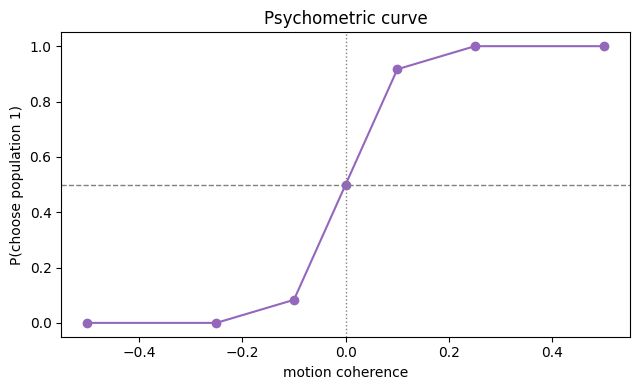

In [5]:
coherences = [-0.5, -0.25, -0.1, 0.0, 0.1, 0.25, 0.5]
n_rep = 12
p_choose_1 = []
for c in coherences:
    wins = 0
    for seed in range(n_rep):
        _, _, _, s1_t, s2_t = run_trial(coherence=c, seed=seed, duration=800.0 * u.ms)
        wins += int(s1_t[-1] > s2_t[-1])
    p_choose_1.append(wins / n_rep)
    print(f"coherence = {c:+.2f}  ->  P(choose pop 1) = {wins / n_rep:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(coherences, p_choose_1, 'o-', color='tab:purple')
ax.axhline(0.5, color='grey', ls='--', lw=1)
ax.axvline(0.0, color='grey', ls=':', lw=1)
ax.set_xlabel('motion coherence'); ax.set_ylabel('P(choose population 1)')
ax.set_ylim(-0.05, 1.05); ax.set_title('Psychometric curve')
plt.tight_layout()
plt.show()

## Summary

The Wong-Wang circuit reproduces the core phenomena of two-choice perceptual decisions:

- **evidence accumulation** — the synaptic gating variables `S1`/`S2` ramp up and one wins,
- **bistability** — under zero evidence, noise alone breaks the symmetry left or right, and
- a **psychometric curve** — choice probability rises smoothly with evidence strength.

{class}`~brainmass.WongWangStep` exposes the rates via `update(coherence=...)` and the gating
state via `model.S1` / `model.S2`. A constant scalar drive like `coherence` is passed directly to
`update`; the noise injected through `noise_s1`/`noise_s2` is what makes individual trials
stochastic. This single-circuit model is the decision-making node you would embed in a larger
network to study distributed choice.